# RM 294 - Optimization I
## Project 3
### Emily Caraher, Mrunal Y Dalvi, Nick Favoriti, Gabriel Kinshuk

---

In [ ]:
import sys
!{sys.executable} -m pip install gurobipy==12.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 42.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import gurobipy as gp
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import optimize
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the dataset

In [ ]:
# read csv file
demand_data = pd.read_csv("price_demand_data.csv")

## 1. Simple Linear Regression

In [ ]:
# Fitting the linear model
linear_x = demand_data['price'].to_numpy().reshape(-1, 1)
linear_y = demand_data['demand'].to_numpy()

linear_regression_model = LinearRegression()
linear_regression_model.fit(linear_x, linear_y)

print("coef:", round(float(linear_regression_model.coef_[0]), 3))
print("intercept:", round(float(linear_regression_model.intercept_), 3))

# Checking the fit on the same training data
linear_pred = linear_regression_model.predict(linear_x)

mse = mean_squared_error(linear_y, linear_pred)
rmse = np.sqrt(mse)
r2 = r2_score(linear_y, linear_pred)

print("MSE:", round(float(mse), 3))
print("RMSE:", round(float(rmse), 3))
print("R2:", round(float(r2), 3))

coef: -1367.713
intercept: 1924.718
MSE: 22335.889
RMSE: 149.452
R2: 0.621


## 2. Generating Demand Data

In [ ]:
p_fixed = 1

# Calculate residuals
residuals = linear_y - linear_pred

# Predict demand at p=1
predicted_demand_at_p1 = linear_regression_model.predict([[p_fixed]])[0]

n_scenarios = len(residuals)

demand_scenarios = predicted_demand_at_p1 + residuals

print(f"Predicted demand at p={p_fixed}:", round(float(predicted_demand_at_p1), 3))
print(f"Number of scenarios:", n_scenarios)
print(f"Mean of generated demands:", round(float(np.mean(demand_scenarios)), 3))
print(f"Std of generated demands:", round(float(np.std(demand_scenarios)), 3))

Predicted demand at p=1: 557.005
Number of scenarios: 99
Mean of generated demands: 557.005
Std of generated demands: 149.452


## 3. Optimal Quantity When $p=1$

In [ ]:
c_val = 0.5
g_val = 0.75
t_val = 0.15

In [ ]:
n = len(demand_scenarios)

model = gp.Model("newsvendor")
q = model.addVar(name="q", lb=0)
h = model.addVars(n, name="h", lb=-gp.GRB.INFINITY)
u = model.addVars(n, lb=0, name="u")
v = model.addVars(n, lb=0, name="v")

model.setObjective((1/n) * gp.quicksum(h[i] for i in range(n)), gp.GRB.MAXIMIZE)

for i in range(n):
    D_i = demand_scenarios[i]
    model.addConstr(h[i] <= p_fixed * D_i - c_val * q - g_val * u[i] - t_val * v[i])
    model.addConstr(h[i] <= p_fixed * q - c_val * q - g_val * u[i] - t_val * v[i])
    model.addConstr(u[i] >= D_i - q)
    model.addConstr(v[i] >= q - D_i)

model.Params.OutputFlag = 0
model.optimize()

if model.status == gp.GRB.OPTIMAL:
    print(f"Price p = {p_fixed}")
    print(f"Optimal quantity q = {q.X:.3f}")
    print(f"Expected profit = {model.objVal:.3f}")
else:
    print("Optimization failed")

Restricted license - for non-production use only - expires 2026-11-23
Price p = 1
Optimal quantity q = 628.543
Expected profit = 178.994


## 4. Optimal Price & Quantity When Price Impacts Demand (QCP)

In [ ]:
# Parameters
# c_val = 0.5
# g_val = 0.75
# t_val = 0.15

def solve_nlp_newsvendor(residuals, beta_0, beta_1, c, g, t):
    n = len(residuals)

    # Initialize Gurobi Model
    model = gp.Model("newsvendor_qp")
    model.Params.OutputFlag = 0  # Silence Gurobi output

    # --- Decision Variables ---
    # p: Price (Continuous, non-negative)
    # q: Quantity (Continuous, non-negative)
    p = model.addVar(lb=0, name="p")
    q = model.addVar(lb=0, name="q")

    # h: Auxiliary variables for Negative Cost (one per scenario)
    # We maximize h, so it acts as the "min" of the two profit scenarios.
    # Must be unbounded below because profit/cost can be negative.
    h = model.addVars(n, lb=-gp.GRB.INFINITY, name="h")

    # --- Objective Function ---
    # Maximize Expected Profit = Expected Revenue + Expected Negative Cost
    # Revenue = p * Demand = p * (beta_0 + beta_1 * p) = beta_0*p + beta_1*p^2
    # Note: The mean of residuals is 0, so we don't include them in the expected revenue term.
    revenue_part = beta_0 * p + beta_1 * p * p

    # Expected Negative Cost = Average of h_i
    avg_h = gp.quicksum(h[i] for i in range(n)) / n

    model.setObjective(revenue_part + avg_h, gp.GRB.MAXIMIZE)

    # --- Constraints ---
    # We linearize the cost function using the "max" logic inverted for maximization.
    # Profit_i = Revenue_i - Cost_i
    # We handle the Cost_i part via h_i:
    # h_i <= -Cost(Overproduction)
    # h_i <= -Cost(Underproduction)

    for i in range(n):
        # Demand for this specific scenario residual
        # D_i depends on p: D_i = beta_0 + beta_1*p + residual_i
        # Since D is inside the constraint, we must substitute the expression.
        eps = residuals[i]

        # 1. Underproduction Case (Demand > Qty) -> Rush Order Cost
        # Cost = c*q + g*(D - q) = (c-g)q + g*D
        # h_i <= - [ (c-g)q + g*(beta_0 + beta_1*p + eps) ]
        # Rearranging: h_i <= (g-c)q - g*beta_0 - g*beta_1*p - g*eps
        model.addConstr(h[i] <= (g - c) * q - g * (beta_0 + beta_1 * p + eps))

        # 2. Overproduction Case (Qty > Demand) -> Disposal Cost
        # Cost = c*q + t*(q - D) = (c+t)q - t*D
        # h_i <= - [ (c+t)q - t*(beta_0 + beta_1*p + eps) ]
        # Rearranging: h_i <= -(c+t)q + t*beta_0 + t*beta_1*p + t*eps
        model.addConstr(h[i] <= -(c + t) * q + t * (beta_0 + beta_1 * p + eps))

    # --- Optimization ---
    model.optimize()

    if model.status == gp.GRB.OPTIMAL:
        return p.X, q.X, model.objVal
    else:
        # Fallback (should not happen for a valid QP)
        return None, None, None

# Run the optimization for the main dataset using the new function
beta_0 = linear_regression_model.intercept_
beta_1 = linear_regression_model.coef_[0]
residuals = linear_y - linear_pred

p_opt, q_opt, profit_opt = solve_nlp_newsvendor(residuals, beta_0, beta_1, c_val, g_val, t_val)

print(f"Optimal price p = {p_opt:.3f}")
print(f"Optimal quantity q = {q_opt:.3f}")
print(f"Expected profit = {profit_opt:.3f}")

Optimal price p = 0.954
Optimal quantity q = 535.291
Expected profit = 234.425


## 6. How Sensitive Is the Optimal Price & Quantity to the Data Set?

In [ ]:
# Perform a single bootstrap iteration
n_samples = len(demand_data)
bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)
bootstrap_data = demand_data.iloc[bootstrap_indices].reset_index(drop=True)

# 1. Fit new regression on bootstrapped data
X_boot = bootstrap_data['price'].values.reshape(-1, 1)
y_boot = bootstrap_data['demand'].values

model_boot = LinearRegression()
model_boot.fit(X_boot, y_boot)

beta_0_boot = model_boot.intercept_
beta_1_boot = model_boot.coef_[0]

# 2. Get new residuals
y_pred_boot = model_boot.predict(X_boot)
residuals_boot = y_boot - y_pred_boot

# 3. Solve optimization for this scenario
p_boot, q_boot, profit_boot = solve_nlp_newsvendor(residuals_boot, beta_0_boot, beta_1_boot, c_val, g_val, t_val)

print("Single Bootstrap Iteration Results:")
print(f"Original Beta_1: {beta_1:.3f} -> Bootstrapped Beta_1: {beta_1_boot:.3f}")
print(f"Original Price: {p_opt:.3f} -> Bootstrapped Price: {p_boot:.3f}")
print(f"Original Qty:   {q_opt:.3f} -> Bootstrapped Qty:   {q_boot:.3f}")

Single Bootstrap Iteration Results:
Original Beta_1: -1367.713 -> Bootstrapped Beta_1: -1460.084
Original Price: 0.954 -> Bootstrapped Price: 0.928
Original Qty:   535.291 -> Bootstrapped Qty:   525.411


## 7. Finding Optimal Price & Quantity to Repeatedly Boostrapped Data

Running 100 bootstrap iterations...
Infeasible solutions: 0 out of 100


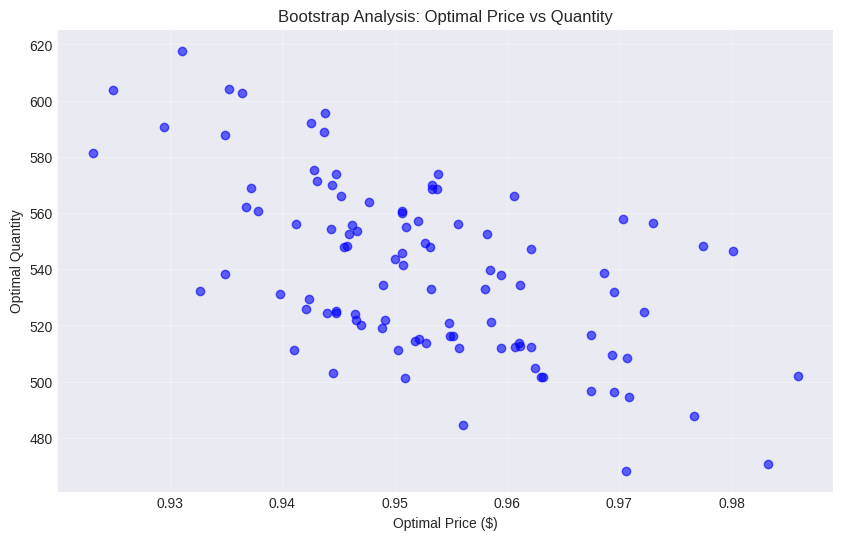

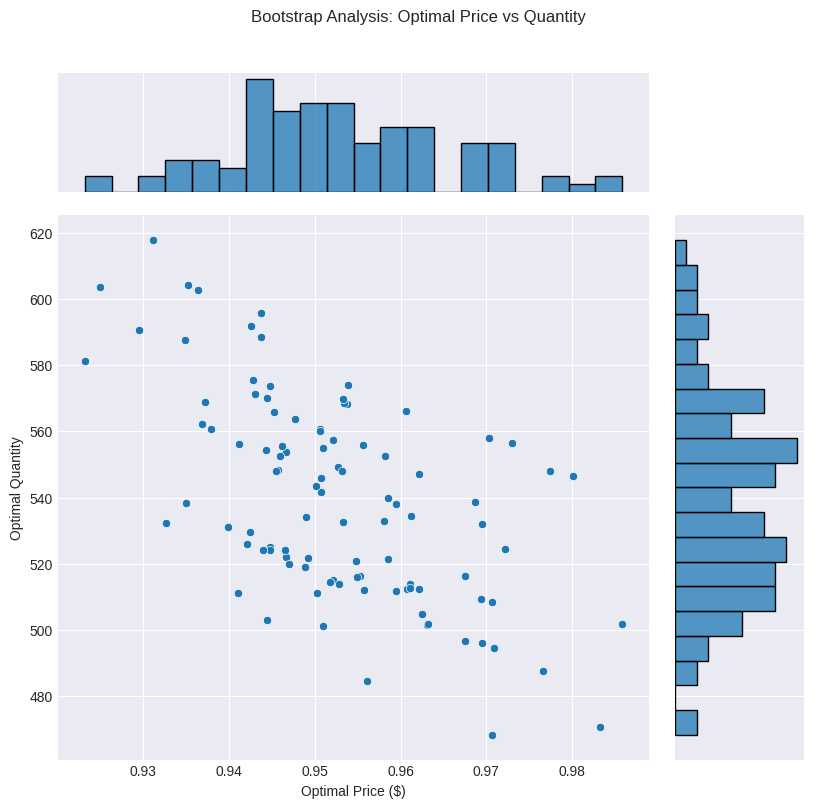

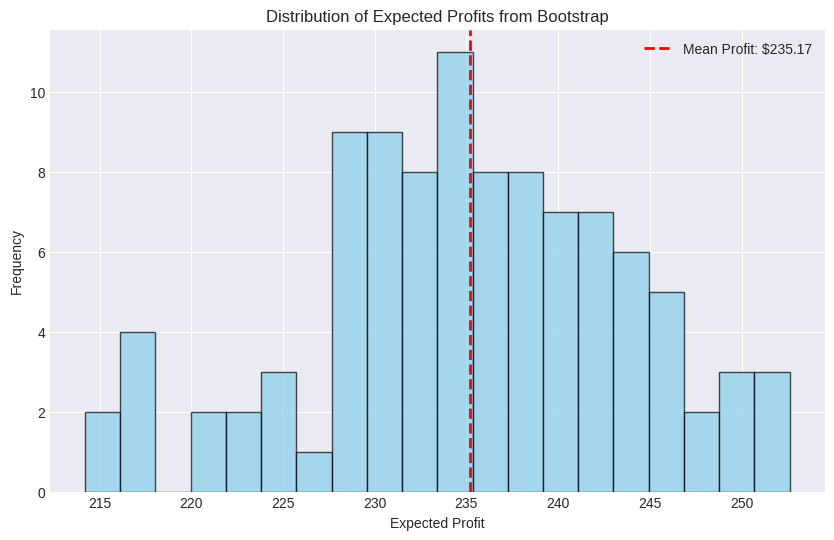

Mean Price: 0.953, Std Price: 0.013
Mean Qty: 539.255, Std Qty: 30.723


In [ ]:
# Run Repeated Bootstrap (100 iterations)
n_iterations = 100
results = {'price': [], 'quantity': [], 'profit': [], 'beta_1': []}
infeasible_count = 0

print(f"Running {n_iterations} bootstrap iterations...")

for i in range(n_iterations):
    # Resample
    indices = np.random.choice(len(demand_data), len(demand_data), replace=True)
    data_boot = demand_data.iloc[indices]

    # Refit
    X_b = data_boot['price'].values.reshape(-1, 1)
    y_b = data_boot['demand'].values
    m_boot = LinearRegression().fit(X_b, y_b)

    # Resolve
    res_boot = y_b - m_boot.predict(X_b)
    p_b, q_b, prof_b = solve_nlp_newsvendor(res_boot, m_boot.intercept_, m_boot.coef_[0], c_val, g_val, t_val)

    if p_b is not None:
        results['price'].append(p_b)
        results['quantity'].append(q_b)
        results['profit'].append(prof_b)
        results['beta_1'].append(m_boot.coef_[0])
    else:
      infeasible_count += 1

print(f"Infeasible solutions: {infeasible_count} out of {n_iterations}")

# --- Visualizations ---
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Price vs Quantity Scatter
plt.figure(figsize=(10, 6))
plt.scatter(results['price'], results['quantity'], alpha=0.6, c='blue')
plt.xlabel('Optimal Price ($)')
plt.ylabel('Optimal Quantity')
plt.title('Bootstrap Analysis: Optimal Price vs Quantity')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Joint Plot (Scatter + Histograms)
g = sns.jointplot(x=results['price'], y=results['quantity'], kind='scatter', height=8, ratio=4, marginal_kws=dict(bins=20, fill=True))
g.set_axis_labels('Optimal Price ($)', 'Optimal Quantity')
g.fig.suptitle('Bootstrap Analysis: Optimal Price vs Quantity')
plt.subplots_adjust(top=0.9)
plt.show()

# 3. Profit Histogram
plt.figure(figsize=(10, 6))
plt.hist(results['profit'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(results['profit']), color='red', linestyle='--', linewidth=2, label=f'Mean Profit: ${np.mean(results["profit"]):.2f}')
plt.xlabel('Expected Profit')
plt.ylabel('Frequency')
plt.title('Distribution of Expected Profits from Bootstrap')
plt.legend()
plt.show()

print(f"Mean Price: {np.mean(results['price']):.3f}, Std Price: {np.std(results['price']):.3f}")
print(f"Mean Qty: {np.mean(results['quantity']):.3f}, Std Qty: {np.std(results['quantity']):.3f}")

## 8. Could we increase revenue by switching models for production/pricing decisions?

In [ ]:
# Compare Optimized Model vs Standard Newsvendor (Boss's Approach)

# 1. Standard Model (Fixed Price)
# Assumes we just use the average historical price and demand
avg_price = demand_data['price'].mean()
avg_demand = demand_data['demand'].mean()
std_demand = demand_data['demand'].std()

# Critical fractile for standard normal calculation
# ratio = (p - c) / p (simplified, assuming no rush/disposal initially for planning)
critical_ratio = (avg_price - c_val) / avg_price
from scipy import stats
z_score = stats.norm.ppf(critical_ratio)
q_standard = avg_demand + z_score * std_demand

# Calculate actual expected profit of Standard Model using our cost structure
def calc_profit(q, price, demands):
    profits = []
    for d in demands:
        sales = min(q, d)
        rush = max(0, d - q)
        disp = max(0, q - d)
        profit = price * sales - c_val * q - g_val * rush - t_val * disp
        profits.append(profit)
    return np.mean(profits)

profit_standard = calc_profit(q_standard, avg_price, demand_data['demand'].values)

# 2. Print Comparison
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"1. STANDARD MODEL (Fixed Avg Price):")
print(f"   Price: ${avg_price:.2f}")
print(f"   Order Qty: {q_standard:.2f}")
print(f"   Expected Profit: ${profit_standard:.2f}")

print(f"\n2. OPTIMIZED MODEL (Dynamic Price):")
print(f"   Price: ${p_opt:.2f}")
print(f"   Order Qty: {q_opt:.2f}")
print(f"   Expected Profit: ${profit_opt:.2f}")

improvement = profit_opt - profit_standard
print(f"\nPROFIT IMPROVEMENT: ${improvement:.2f} (+{(improvement/profit_standard)*100:.1f}%)")

MODEL COMPARISON
1. STANDARD MODEL (Fixed Avg Price):
   Price: $1.02
   Order Qty: 538.14
   Expected Profit: $84.13

2. OPTIMIZED MODEL (Dynamic Price):
   Price: $0.95
   Order Qty: 535.29
   Expected Profit: $234.42

PROFIT IMPROVEMENT: $150.30 (+178.7%)


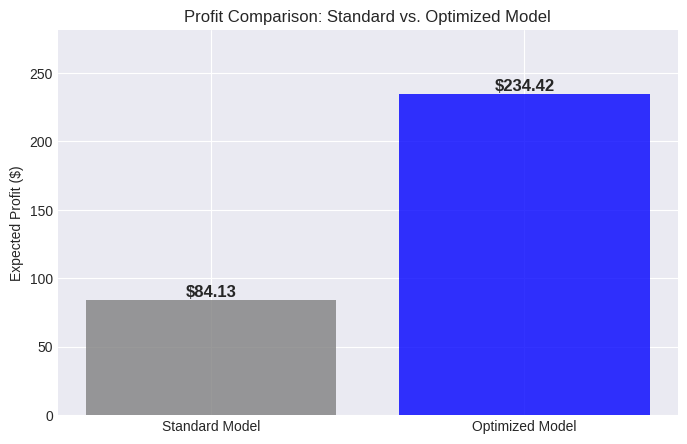

In [ ]:
# Comparison Bar Chart
models = ['Standard Model', 'Optimized Model']
profits = [profit_standard, profit_opt]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, profits, color=['gray', 'blue'], alpha=0.8)

# Add text labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Expected Profit ($)')
plt.title('Profit Comparison: Standard vs. Optimized Model')
plt.ylim(0, max(profits) * 1.2) # Give some headroom
plt.show()